量子迁移学习
=============

简介
----

迁移学习是一种成熟的人工神经网络训练技术(参见\[2\])。其基本思路是，如果一个预训练的网络已经能很好地解决一个问题，那么经过少量额外训练，它也可以用来解决一个不同但相关的问题。

正如\[1\]中所讨论的，这一思想可以用两个抽象网络 $A$ 和 $B$ 来形式化描述，与它们的量子或经典物理本质无关。

<div style="margin-right: 15px; border-radius: 10px; background-color: rgb(255， 255， 255); text-align: center;">
    <img src="./images/3_8_0001.png" width="40%"/>
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        <b>
    </p>
</div>

如上图所示,我们可以给出迁移学习方法的**一般定义**:

1.  选取一个在数据集 $D_A$ 上为任务 $T_A$ 预训练过的网络 $A$ 。
2.  移除一些末端层。这样截断后的网络 $A'$ 可以作为特征提取器使用。
3.  在预训练网络 $A'$ 的末端连接一个新的可训练网络 $B$ 。
4.  固定 $A'$ 的权重，用新的数据集 $D_B$ 或感兴趣的新任务 $T_B$ 训练末端模块 $B$ 。

当处理混合系统时，根据网络 $A$ 和 $B$ 的物理性质（经典或量子），可以有不同的迁移学习实现方式，总结如下表：

  -------------------------------------------------------------------------
  Network A   Network B   Transfer learning scheme
  ----------- ----------- -------------------------------------------------
  经典           经典          CC - Standard classical method. See e.g., Ref.\[2\].

  经典           量子          CQ - **Hybrid model presented in this tutorial.**

  量子           经典          QC - Model studied in Ref. \[1\].

  量子           量子          QQ - Model studied in Ref. \[1\].

  -------------------------------------------------------------------------


经典-量子迁移学习
-----------------

我们聚焦于上一节讨论的CQ迁移学习方案，给出一个具体示例。

1.  作为预训练网络 $A$，我们使用**ResNet18**，这是微软在\[3\]中提出的一种深度残差神经网络，在*ImageNet*数据集上预训练。
2.  移除其最后一层后，我们得到 $A'$ ，一个将任意高分辨率输入图像映射为512个抽象特征的预处理模块。
3.  这些特征由一个4比特的"量子线路" $B$ 进行分类，即夹在两个经典层之间的变分量子线路。
4.  保持 $A'$ 不变，在*Hymenoptera*数据集（ImageNet的一个小子集）上训练该混合模型，其中包含*蚂蚁*和*蜜蜂*的图像。

模型主要超参数设置
==================

In [4]:
import copy
import os
import time

import deepquantum as dq
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.optim import lr_scheduler
from torchvision import datasets, transforms

torch.manual_seed(42)
np.random.seed(42)

# OpenMP: 设置并行线程数量
os.environ['OMP_NUM_THREADS'] = '1'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

n_qubits = 4  # 量子比特数
step = 0.01  # 学习步长
batch_size = 4  # 每次训练的样本数量
num_epochs = 3  # 训练的总轮次
q_depth = 6  # 量子电路的深度（变分层的数量）
gamma_lr_scheduler = 0.1  # 每10个训练周期应用一次的学习率减少比例
q_delta = 0.01  # 量子权重的初始随机扩散
start_time = time.time()  # 开始计算的时间

数据集加载
==========

这是一个非常小的数据集（大约250张图像，包含*蚂蚁*和*蜜蜂*图像的数据集，可以在[这里](https://download.pytorch.org/tutorial/hymenoptera_data.zip)下载），太小而无法从头开始训练经典或量子模型，但在使用*迁移学习*方法时已经足够了。

PyTorch包`torchvision`和`torch.utils.data`用于加载数据集并执行标准的预备图像操作：调整大小、居中、裁剪、归一化等。

In [5]:
# 数据预处理的设置
data_transforms = {
    'train': transforms.Compose(
        [
            # 若需要数据增强，请取消下列两行的注释
            # transforms.RandomResizedCrop(224),
            # transforms.RandomHorizontalFlip(),
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            # 使用ImageNet的均值和标准差对输入通道进行归一化
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    ),
    'val': transforms.Compose(
        [
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    ),
}

# 数据目录和图片数据集的定义
data_dir = './data'
image_datasets = {
    'train' if x == 'train' else 'validation': datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'val']
}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'validation']}
class_names = image_datasets['train'].classes

# 初始化数据加载器
dataloaders = {
    x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True)
    for x in ['train', 'validation']
}


# 定义用于展示图片的函数
def imshow(inp, title=None):
    """从张量显示图像。"""
    inp = inp.numpy().transpose((1, 2, 0))
    # 反向执行最初的归一化操作
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)

让我们展示一批测试数据，以对分类问题有个概念。

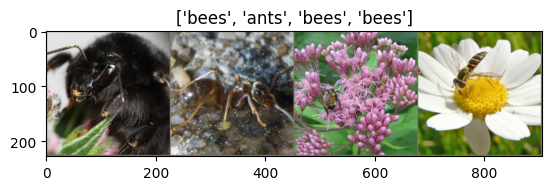

In [6]:
# 获取一批验证数据
inputs, classes = next(iter(dataloaders['validation']))

# 将批次数据转换为网格形式
out = torchvision.utils.make_grid(inputs)

# 显示图像网格，并标注各图像对应的类别名称
imshow(out, title=[class_names[x] for x in classes])

# 重新初始化数据加载器
dataloaders = {
    x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True)
    for x in ['train', 'validation']
}

变分量子线路
============

我们首先定义一些构成量子线路的量子层。

现在我们通过DeepQuantum定义量子线路。

其结构是一个典型的变分量子线路:

该模块的输入是一批具有512个实数参数（特征）的向量，输出是一批具有两个实数输出的向量（对应于图像的两个类别：*蚂蚁*和*蜜蜂*）。

In [7]:
## 定义VQC模块
class QuLinear(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        n_qubits = input_size  # 定义比特个数
        self.cir = dq.QubitCircuit(n_qubits, reupload=True)
        self.cir.hlayer()
        self.cir.rylayer(encode=True)
        self.cir.rzlayer(encode=True)
        self.cir.barrier()
        self.cir.cnot_ring()
        self.cir.barrier()
        self.cir.cnot_ring(step=2)
        self.cir.barrier()
        self.cir.u3layer()

        for i in range(hidden_size):  # 以for循环
            self.cir.observable(wires=i, basis='z')

    def forward(self, x):
        ry_parameter = torch.arctan(x)  # 将经典数据转化为对应ry的角度
        rz_parameter = torch.arctan(x * x)  # 将经典数据转化为对应rz的角度
        r_parameter = torch.cat([ry_parameter, rz_parameter], dim=1)
        self.cir(r_parameter)
        return self.cir.expectation()

In [8]:
class QuantumNet(nn.Module):
    """定义一个名为“QuantumNet”的Torch模块。"""

    def __init__(self):
        """初始化量子网络的结构。"""
        super().__init__()
        self.pre_net = nn.Linear(512, n_qubits)  # 将输入特征维度从512降至量子位数
        self.Qulinear = QuLinear(n_qubits, n_qubits)
        self.post_net = nn.Linear(n_qubits, 2)  # 后处理网络，将量子位输出映射到两个输出类别

    def forward(self, input_features):
        """定义输入特征通过“dressed”量子网络的传递方式。"""
        # 使用前处理网络减小特征维度，并将结果缩放到π/2的范围内
        pre_out = self.pre_net(input_features)
        q_in = torch.tanh(pre_out / 10) * np.pi / 2.0

        # 为每个批次元素应用量子电路，并收集输出到q_out
        q_out = self.Qulinear(q_in)

        # 通过后处理网络返回二维预测结果
        return self.post_net(q_out)

混合经典-量子模型
=================

我们终于准备好构建完整的混合经典-量子网络了。我们遵循*迁移学习*的方法:

1. 首先从`torchvision.models`库中加载经典预训练网络*ResNet18*。
2. 冻结所有权重,因为它们不应该被训练。
3. 将最后一个全连接层替换为我们的可训练装饰量子线路（`DressedQuantumNet`）。


In [9]:
# 加载预训练权重
weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1
model_hybrid = torchvision.models.resnet18(weights=weights)

# 冻结模型的所有参数，防止在训练过程中更新
for param in model_hybrid.parameters():
    param.requires_grad = False

# 注意，model_hybrid.fc 是 ResNet18 的最后一层
model_hybrid.fc = QuantumNet()

# 根据设备对象选择使用 CUDA 还是 CPU
model_hybrid = model_hybrid.to(device)

训练和结果
==========

在训练网络之前，我们需要指定*损失*函数。

在分类问题中,我们通常使用*交叉熵*，它可以直接在`torch.nn`中获得。

In [10]:
criterion = nn.CrossEntropyLoss()

我们还初始化了*Adam优化器*，它在每个训练步骤都会被调用以更新模型的权重。

In [11]:
optimizer_hybrid = optim.Adam(model_hybrid.fc.parameters(), lr=step)

我们计划每10个epoch将学习率降低`gamma_lr_scheduler`倍。

In [12]:
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_hybrid, step_size=10, gamma=gamma_lr_scheduler)

接下来是一个稍后将被调用的训练函数。该函数应返回一个经过训练的模型，可用于进行预测（分类）。

我们准备执行实际的训练过程。

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_loss = 10000.0  # 初始化最佳损失为一个较大的数值
    best_acc_train = 0.0
    best_loss_train = 10000.0  # 初始化训练过程中的最佳损失为一个较大的数值
    print('Training started:')

    for epoch in range(num_epochs):
        # 每个epoch都有训练和验证两个阶段
        for phase in ['train', 'validation']:
            if phase == 'train':
                model.train()  # 设置模型为训练模式
            else:
                model.eval()  # 设置模型为评估模式

            running_loss = 0.0
            running_corrects = 0

            # 遍历数据
            n_batches = dataset_sizes[phase] // batch_size

            for iter_, (inputs, labels) in enumerate(dataloaders[phase]):
                since_batch = time.time()
                batch_size_ = len(inputs)
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                # 在训练阶段计算梯度并进行优化
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # 打印批处理结果
                running_loss += loss.item() * batch_size_
                batch_corrects = torch.sum(preds == labels.data).item()
                running_corrects += batch_corrects
                print(
                    f'Phase: {phase} Epoch: {epoch + 1}/{num_epochs} Iter: {iter_ + 1}/{n_batches + 1}'
                    f'Batch time: {time.time() - since_batch:.4f}',
                    end='\r',
                    flush=True,
                )

            # 打印每个epoch的结果
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            print(
                f'Phase: {"train" if phase == "train" else "validation  "} Epoch: {epoch + 1}/{num_epochs}'
                f'Loss:{epoch_loss:.4f} Acc: {epoch_acc:.4f}'
            )

            # 更新最佳模型（基于验证准确率和损失）
            if phase == 'validation':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
            if phase == 'train':
                if epoch_acc > best_acc_train:
                    best_acc_train = epoch_acc
                if epoch_loss < best_loss_train:
                    best_loss_train = epoch_loss

            # 更新学习率
            if phase == 'train':
                scheduler.step()

    # 打印最终结果
    model.load_state_dict(best_model_wts)
    time_elapsed = time.time() - since
    print(f'Training completed in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best validation loss: {best_loss:.4f} | Best validation accuracy: {best_acc:.4f}')
    return model

In [14]:
model_hybrid = train_model(model_hybrid, criterion, optimizer_hybrid, exp_lr_scheduler, num_epochs=num_epochs)

Training started:
Phase: train Epoch: 1/3 Loss: 0.6258 Acc: 0.6967        
Phase: validation   Epoch: 1/3 Loss: 0.4652 Acc: 0.9346        
Phase: train Epoch: 2/3 Loss: 0.5323 Acc: 0.7541        
Phase: validation   Epoch: 2/3 Loss: 0.4719 Acc: 0.8824        
Phase: train Epoch: 3/3 Loss: 0.6241 Acc: 0.6639        
Phase: validation   Epoch: 3/3 Loss: 0.4885 Acc: 0.9412        
Training completed in 0m 10s
Best validation loss: 0.4652 | Best validation accuracy: 0.9412


可视化模型预测
==============

我们首先为一批测试数据定义一个可视化函数。

In [15]:
def visualize_model(model, num_images=6, fig_name='Predictions'):
    images_so_far = 0
    _fig = plt.figure(fig_name)
    model.eval()
    with torch.no_grad():
        for _i, (inputs, labels) in enumerate(dataloaders['validation']):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images // 2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'[{class_names[preds[j]]}]')
                imshow(inputs.cpu().data[j])
                if images_so_far == num_images:
                    return

最后，我们可以运行前面的函数，查看一批图像及其对应的预测。

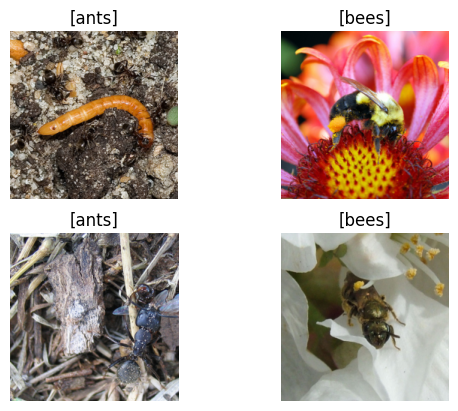

In [16]:
visualize_model(model_hybrid, num_images=batch_size)
plt.show()

# 参考文献

[1] Mari A, Bromley T R, Izaac J, et al. Transfer learning in hybrid classical-quantum neural networks[J]. Quantum, 2020, 4: 340.

[2] Raina R, Battle A, Lee H, et al. Self-taught learning: transfer learning from unlabeled data[C]//Proceedings of the 24th international conference on Machine learning. 2007: 759-766.

[3] He K, Zhang X, Ren S, et al. Deep residual learning for image recognition[C]//Proceedings of the IEEE conference on computer vision and pattern recognition. 2016: 770-778.